In [1]:
from pathlib import Path
import pickle
import sys


# ---------------------------------------------------------
# Restore project root
# ---------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ---------------------------------------------------------
# Locate cached landmark sequences
# ---------------------------------------------------------

LANDMARK_CACHE_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "landmarks"
)

train_cache = LANDMARK_CACHE_DIR / "train_sequences.pkl"
validation_cache = LANDMARK_CACHE_DIR / "validation_sequences.pkl"


# ---------------------------------------------------------
# Load cached sequences
# ---------------------------------------------------------

assert train_cache.exists(), (
    f"Train cache not found: {train_cache}"
)

assert validation_cache.exists(), (
    f"Validation cache not found: {validation_cache}"
)


with open(train_cache, "rb") as file:
    train_sequences = pickle.load(file)

with open(validation_cache, "rb") as file:
    validation_sequences = pickle.load(file)


print("✓ Cached landmarks loaded")
print(f"Train: {len(train_sequences)}")
print(f"Validation: {len(validation_sequences)}")

✓ Cached landmarks loaded
Train: 2484
Validation: 633


In [2]:
# Restore imports and experiment configuration after kernel restart

import random
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence


# Experiment configuration
BATCH_SIZE = 32
RANDOM_STATE = 42
SEED = 42

INPUT_SIZE = 63
HIDDEN_SIZE = 128
NUM_LAYERS = 1
NUM_CLASSES = 13

LEARNING_RATE = 1e-3
NUM_EPOCHS = 15

EXPERIMENT_STRATEGIES = [
    "fixed_192",
    "fixed_256",
    "hybrid",
]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {DEVICE}")
print(f"Train sequences: {len(train_sequences)}")
print(f"Validation sequences: {len(validation_sequences)}")

Device: cpu
Train sequences: 2484
Validation sequences: 633


In [3]:
# IPN gesture IDs are 2–14 because D0X (ID 1) was excluded.
# Convert them to PyTorch class indices 0–12.

train_class_indices = np.asarray(
    [sequence.class_id for sequence in train_sequences]
) - 2

validation_class_indices = np.asarray(
    [sequence.class_id for sequence in validation_sequences]
) - 2

print(
    "Train label range:",
    train_class_indices.min(),
    "to",
    train_class_indices.max(),
)

print(
    "Validation label range:",
    validation_class_indices.min(),
    "to",
    validation_class_indices.max(),
)

Train label range: 0 to 12
Validation label range: 0 to 12


In [4]:
class GestureDataset(Dataset):
    """
    PyTorch dataset for the 13 IPN gesture classes.

    IPN gesture IDs 2–14 → PyTorch indices 0–12.
    """
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = np.asarray(labels) - 2

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        sequence = torch.tensor(
            self.sequences[index],
            dtype=torch.float32,
        )
        label = torch.tensor(
            self.labels[index],
            dtype=torch.long,
        )
        return sequence, label


def collate_sequences(batch):
    sequences, labels = zip(*batch)

    padded_sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0.0,
    )

    lengths = torch.tensor(
        [sequence.shape[0] for sequence in sequences],
        dtype=torch.long,
    )

    labels = torch.stack(labels)

    return padded_sequences, lengths, labels

In [6]:
SHORT_SEQUENCE_LIMIT = 192
LONG_SEQUENCE_LIMIT = 256


def resample_sequence(sequence, target_length):
    """Resample a landmark sequence to a target number of timesteps."""
    original_length = sequence.shape[0]

    if original_length == target_length:
        return sequence.copy()

    original_positions = np.linspace(
        0,
        original_length - 1,
        num=original_length,
    )

    target_positions = np.linspace(
        0,
        original_length - 1,
        num=target_length,
    )

    resampled = np.empty(
        (target_length, sequence.shape[1]),
        dtype=np.float32,
    )

    for feature_index in range(sequence.shape[1]):
        resampled[:, feature_index] = np.interp(
            target_positions,
            original_positions,
            sequence[:, feature_index],
        )

    return resampled


def prepare_sequence(sequence, strategy):
    """Apply one temporal preprocessing strategy."""

    sequence_length = sequence.shape[0]

    if strategy == "fixed_192":
        return resample_sequence(
            sequence,
            SHORT_SEQUENCE_LIMIT,
        )

    if strategy == "fixed_256":
        return resample_sequence(
            sequence,
            LONG_SEQUENCE_LIMIT,
        )

    if strategy == "hybrid":
        if sequence_length < SHORT_SEQUENCE_LIMIT:
            target_length = sequence_length
        elif sequence_length <= LONG_SEQUENCE_LIMIT:
            target_length = SHORT_SEQUENCE_LIMIT
        else:
            target_length = LONG_SEQUENCE_LIMIT

        return resample_sequence(
            sequence,
            target_length,
        )

    raise ValueError(
        f"Unknown temporal strategy: {strategy}"
    )


def prepare_dataset(sequences, strategy):
    """Prepare all sequences using the selected temporal strategy."""

    X = []
    y = []

    for sequence in sequences:
        processed = prepare_sequence(
            sequence.landmarks,
            strategy,
        )

        X.append(processed)
        y.append(sequence.class_id)

    return X, np.array(y)

In [7]:
prepared_datasets = {}

for strategy in EXPERIMENT_STRATEGIES:
    train_X, train_y = prepare_dataset(
        train_sequences,
        strategy,
    )

    validation_X, validation_y = prepare_dataset(
        validation_sequences,
        strategy,
    )

    prepared_datasets[strategy] = {
        "train_X": train_X,
        "train_y": train_y,
        "validation_X": validation_X,
        "validation_y": validation_y,
    }


train_loaders = {}
validation_loaders = {}

for strategy in EXPERIMENT_STRATEGIES:
    train_dataset = GestureDataset(
        prepared_datasets[strategy]["train_X"],
        prepared_datasets[strategy]["train_y"],
    )

    validation_dataset = GestureDataset(
        prepared_datasets[strategy]["validation_X"],
        prepared_datasets[strategy]["validation_y"],
    )

    train_loaders[strategy] = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_sequences,
    )

    validation_loaders[strategy] = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_sequences,
    )

print("DataLoaders ready.")

DataLoaders ready.


In [8]:
batch_sequences, batch_lengths, batch_labels = next(
    iter(train_loaders["fixed_192"])
)

print("Sequences:", batch_sequences.shape)
print("Lengths:", batch_lengths.shape)
print("Labels:", batch_labels.shape)
print("Label range:", batch_labels.min().item(), "to", batch_labels.max().item())

Sequences: torch.Size([32, 192, 63])
Lengths: torch.Size([32])
Labels: torch.Size([32])
Label range: 0 to 12


In [9]:
class GestureGRU(nn.Module):
    def __init__(
        self,
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.classifier = nn.Linear(
            hidden_size,
            num_classes,
        )

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        _, hidden = self.gru(packed)

        final_hidden = hidden[-1]

        logits = self.classifier(final_hidden)

        return logits

In [10]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def create_training_components(model):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )

    return criterion, optimizer


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for sequences, lengths, labels in loader:
        sequences = sequences.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits = model(sequences, lengths)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for sequences, lengths, labels in loader:
            sequences = sequences.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(sequences, lengths)

            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)

            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [11]:
set_seed()

model = GestureGRU().to(DEVICE)

criterion, optimizer = create_training_components(model)

print(
    f"Parameters: {sum(p.numel() for p in model.parameters()):,}"
)

print("Starting fixed-192 training...")

Parameters: 75,789
Starting fixed-192 training...


In [12]:
NUM_EPOCHS = 15

history = []

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loaders["fixed_192"],
        criterion,
        optimizer,
    )

    validation_loss, validation_accuracy = evaluate(
        model,
        validation_loaders["fixed_192"],
        criterion,
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "validation_loss": validation_loss,
        "validation_accuracy": validation_accuracy,
    })

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {validation_loss:.4f} | "
        f"Val Acc: {validation_accuracy:.4f}"
    )

history_df = pd.DataFrame(history)

Epoch 01/15 | Train Loss: 2.3112 | Train Acc: 0.2540 | Val Loss: 2.1580 | Val Acc: 0.2938
Epoch 02/15 | Train Loss: 2.0570 | Train Acc: 0.2834 | Val Loss: 1.9378 | Val Acc: 0.2622
Epoch 03/15 | Train Loss: 1.8314 | Train Acc: 0.3921 | Val Loss: 1.6011 | Val Acc: 0.5024
Epoch 04/15 | Train Loss: 1.5798 | Train Acc: 0.4835 | Val Loss: 1.3840 | Val Acc: 0.5656
Epoch 05/15 | Train Loss: 1.3490 | Train Acc: 0.5761 | Val Loss: 1.1442 | Val Acc: 0.6240
Epoch 06/15 | Train Loss: 1.1882 | Train Acc: 0.6159 | Val Loss: 1.1150 | Val Acc: 0.5908
Epoch 07/15 | Train Loss: 1.0905 | Train Acc: 0.6421 | Val Loss: 0.9366 | Val Acc: 0.6840
Epoch 08/15 | Train Loss: 1.0407 | Train Acc: 0.6506 | Val Loss: 0.9223 | Val Acc: 0.6730
Epoch 09/15 | Train Loss: 0.9473 | Train Acc: 0.6812 | Val Loss: 0.8245 | Val Acc: 0.6951
Epoch 10/15 | Train Loss: 0.9093 | Train Acc: 0.6892 | Val Loss: 0.7938 | Val Acc: 0.7283
Epoch 11/15 | Train Loss: 0.8431 | Train Acc: 0.7150 | Val Loss: 0.7474 | Val Acc: 0.7299
Epoch 12/1

In [13]:
def run_experiment(strategy):
    set_seed(SEED)

    experiment_model = GestureGRU().to(DEVICE)

    experiment_criterion, experiment_optimizer = (
        create_training_components(experiment_model)
    )

    history = []

    start_time = time.perf_counter()

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_accuracy = train_one_epoch(
            experiment_model,
            train_loaders[strategy],
            experiment_criterion,
            experiment_optimizer,
        )

        validation_loss, validation_accuracy = evaluate(
            experiment_model,
            validation_loaders[strategy],
            experiment_criterion,
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
        })

        print(
            f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {validation_accuracy:.4f}"
        )

    elapsed_time = time.perf_counter() - start_time

    return {
        "strategy": strategy,
        "model": experiment_model,
        "history": pd.DataFrame(history),
        "elapsed_seconds": elapsed_time,
    }

In [14]:
def run_experiment(strategy):
    set_seed(SEED)

    experiment_model = GestureGRU().to(DEVICE)

    experiment_criterion, experiment_optimizer = (
        create_training_components(experiment_model)
    )

    history = []

    start_time = time.perf_counter()

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_accuracy = train_one_epoch(
            experiment_model,
            train_loaders[strategy],
            experiment_criterion,
            experiment_optimizer,
        )

        validation_loss, validation_accuracy = evaluate(
            experiment_model,
            validation_loaders[strategy],
            experiment_criterion,
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
        })

        print(
            f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {validation_accuracy:.4f}"
        )

    elapsed_time = time.perf_counter() - start_time

    return {
        "strategy": strategy,
        "model": experiment_model,
        "history": pd.DataFrame(history),
        "elapsed_seconds": elapsed_time,
    }

In [15]:
fixed_192_result = run_experiment("fixed_192")

print(
    f"\nFixed-192 training time: "
    f"{fixed_192_result['elapsed_seconds'] / 60:.2f} minutes"
)

Epoch 01/15 | Train Acc: 0.2540 | Val Acc: 0.2938
Epoch 02/15 | Train Acc: 0.2834 | Val Acc: 0.2622
Epoch 03/15 | Train Acc: 0.3921 | Val Acc: 0.5024
Epoch 04/15 | Train Acc: 0.4835 | Val Acc: 0.5656
Epoch 05/15 | Train Acc: 0.5761 | Val Acc: 0.6240
Epoch 06/15 | Train Acc: 0.6159 | Val Acc: 0.5908
Epoch 07/15 | Train Acc: 0.6421 | Val Acc: 0.6840
Epoch 08/15 | Train Acc: 0.6506 | Val Acc: 0.6730
Epoch 09/15 | Train Acc: 0.6812 | Val Acc: 0.6951
Epoch 10/15 | Train Acc: 0.6892 | Val Acc: 0.7283
Epoch 11/15 | Train Acc: 0.7150 | Val Acc: 0.7299
Epoch 12/15 | Train Acc: 0.7146 | Val Acc: 0.7251
Epoch 13/15 | Train Acc: 0.7146 | Val Acc: 0.6840
Epoch 14/15 | Train Acc: 0.7114 | Val Acc: 0.7030
Epoch 15/15 | Train Acc: 0.7210 | Val Acc: 0.7472

Fixed-192 training time: 29.20 minutes


In [16]:
fixed_256_result = run_experiment("fixed_256")

print(
    f"\nFixed-256 training time: "
    f"{fixed_256_result['elapsed_seconds'] / 60:.2f} minutes"
)

Epoch 01/15 | Train Acc: 0.2508 | Val Acc: 0.2812
Epoch 02/15 | Train Acc: 0.2770 | Val Acc: 0.2686
Epoch 03/15 | Train Acc: 0.3837 | Val Acc: 0.4550
Epoch 04/15 | Train Acc: 0.5052 | Val Acc: 0.5419
Epoch 05/15 | Train Acc: 0.5680 | Val Acc: 0.6272
Epoch 06/15 | Train Acc: 0.5894 | Val Acc: 0.5577
Epoch 07/15 | Train Acc: 0.6337 | Val Acc: 0.6983
Epoch 08/15 | Train Acc: 0.6192 | Val Acc: 0.6130
Epoch 09/15 | Train Acc: 0.6610 | Val Acc: 0.7062
Epoch 10/15 | Train Acc: 0.6787 | Val Acc: 0.7062
Epoch 11/15 | Train Acc: 0.6957 | Val Acc: 0.7141
Epoch 12/15 | Train Acc: 0.7242 | Val Acc: 0.7077
Epoch 13/15 | Train Acc: 0.7170 | Val Acc: 0.7188
Epoch 14/15 | Train Acc: 0.7436 | Val Acc: 0.7330
Epoch 15/15 | Train Acc: 0.7242 | Val Acc: 0.7441

Fixed-256 training time: 92.81 minutes


In [17]:
hybrid_result = run_experiment("hybrid")

print(
    f"\nHybrid training time: "
    f"{hybrid_result['elapsed_seconds'] / 60:.2f} minutes"
)

Epoch 01/15 | Train Acc: 0.2585 | Val Acc: 0.2891
Epoch 02/15 | Train Acc: 0.2943 | Val Acc: 0.2954
Epoch 03/15 | Train Acc: 0.3845 | Val Acc: 0.4092
Epoch 04/15 | Train Acc: 0.4328 | Val Acc: 0.5087
Epoch 05/15 | Train Acc: 0.5101 | Val Acc: 0.5671
Epoch 06/15 | Train Acc: 0.5853 | Val Acc: 0.6603
Epoch 07/15 | Train Acc: 0.6135 | Val Acc: 0.6761
Epoch 08/15 | Train Acc: 0.6240 | Val Acc: 0.6461
Epoch 09/15 | Train Acc: 0.6820 | Val Acc: 0.7251
Epoch 10/15 | Train Acc: 0.6985 | Val Acc: 0.7109
Epoch 11/15 | Train Acc: 0.7037 | Val Acc: 0.7014
Epoch 12/15 | Train Acc: 0.7065 | Val Acc: 0.7267
Epoch 13/15 | Train Acc: 0.7355 | Val Acc: 0.7409
Epoch 14/15 | Train Acc: 0.7540 | Val Acc: 0.7520
Epoch 15/15 | Train Acc: 0.7512 | Val Acc: 0.7425

Hybrid training time: 14.97 minutes


In [18]:
experiment_summary = pd.DataFrame([
    {
        "strategy": "fixed_192",
        "final_val_accuracy": fixed_192_result["history"]["validation_accuracy"].iloc[-1],
        "best_val_accuracy": fixed_192_result["history"]["validation_accuracy"].max(),
        "training_time_minutes": fixed_192_result["elapsed_seconds"] / 60,
    },
    {
        "strategy": "fixed_256",
        "final_val_accuracy": fixed_256_result["history"]["validation_accuracy"].iloc[-1],
        "best_val_accuracy": fixed_256_result["history"]["validation_accuracy"].max(),
        "training_time_minutes": fixed_256_result["elapsed_seconds"] / 60,
    },
    {
        "strategy": "hybrid",
        "final_val_accuracy": hybrid_result["history"]["validation_accuracy"].iloc[-1],
        "best_val_accuracy": hybrid_result["history"]["validation_accuracy"].max(),
        "training_time_minutes": hybrid_result["elapsed_seconds"] / 60,
    },
])

experiment_summary

,strategy,final_val_accuracy,best_val_accuracy,training_time_minutes
0,fixed_192,0.747235,0.747235,29.202510
1,fixed_256,0.744076,0.744076,92.814703
2,hybrid,0.742496,0.751975,14.965630


In [19]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
)

hybrid_model = hybrid_result["model"]

hybrid_model.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():
    for sequences, lengths, labels in validation_loaders["hybrid"]:
        sequences = sequences.to(DEVICE)

        logits = hybrid_model(
            sequences,
            lengths,
        )

        predictions = logits.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_true_labels.extend(
            labels.numpy()
        )

all_predictions = np.asarray(all_predictions)
all_true_labels = np.asarray(all_true_labels)

print("Samples:", len(all_true_labels))
print(
    "Prediction accuracy:",
    (all_predictions == all_true_labels).mean()
)

Samples: 633
Prediction accuracy: 0.7424960505529226


In [20]:
gesture_names = [
    "Pointing with one finger",
    "Pointing with two fingers",
    "Click with one finger",
    "Click with two fingers",
    "Throw up",
    "Throw down",
    "Throw left",
    "Throw right",
    "Open twice",
    "Double click with one finger",
    "Double click with two fingers",
    "Zoom in",
    "Zoom out",
]

print(
    classification_report(
        all_true_labels,
        all_predictions,
        target_names=gesture_names,
        digits=3,
    )
)

                               precision    recall  f1-score   support

     Pointing with one finger      1.000     0.941     0.969       152
    Pointing with two fingers      0.925     0.987     0.955       151
        Click with one finger      0.442     0.633     0.521        30
       Click with two fingers      0.143     0.033     0.054        30
                     Throw up      0.714     0.333     0.455        30
                   Throw down      0.893     0.833     0.862        30
                   Throw left      0.900     0.900     0.900        30
                  Throw right      0.917     0.733     0.815        30
                   Open twice      0.541     0.667     0.597        30
 Double click with one finger      0.227     0.167     0.192        30
Double click with two fingers      0.375     0.900     0.529        30
                      Zoom in      0.378     0.567     0.453        30
                     Zoom out      0.714     0.167     0.270        30

    

In [21]:
cm = confusion_matrix(
    all_true_labels,
    all_predictions,
)

cm_df = pd.DataFrame(
    cm,
    index=gesture_names,
    columns=gesture_names,
)

cm_df

,Pointing with one finger,Pointing with two fingers,Click with one finger,Click with two fingers,Throw up,Throw down,Throw left,Throw right,Open twice,Double click with one finger,Double click with two fingers,Zoom in,Zoom out
Pointing with one finger,143,0,2,0,0,0,0,0,0,7,0,0,0
Pointing with two fingers,0,149,0,0,0,0,0,0,0,0,2,0,0
Click with one finger,0,0,19,0,0,0,1,0,0,10,0,0,0
Click with two fingers,0,0,0,1,0,0,0,0,0,0,21,7,1
Throw up,0,0,0,0,10,1,1,0,11,0,0,7,0
Throw down,0,1,0,0,2,25,0,0,1,0,0,1,0
Throw left,0,1,0,0,0,1,27,1,0,0,0,0,0
Throw right,0,0,0,2,0,1,0,22,2,0,1,2,0
Open twice,0,0,0,0,0,0,1,1,20,0,2,5,1
Double click with one finger,0,0,22,0,1,0,0,0,0,5,2,0,0


In [22]:
problematic_labels = {
    4: "Click with one finger",
    5: "Click with two fingers",
    11: "Double click with one finger",
    12: "Double click with two fingers",
    13: "Zoom in",
    14: "Zoom out",
}

length_records = []

for sequence in train_sequences:
    if sequence.class_id in problematic_labels:
        length_records.append({
            "label": problematic_labels[sequence.class_id],
            "length": sequence.landmarks.shape[0],
        })

length_df = pd.DataFrame(length_records)

length_summary = (
    length_df
    .groupby("label")["length"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
    .round(2)
)

length_summary

,count,mean,median,min,max
label,,,,,
Click with one finger,118,55.20,46.0,13,167
Click with two fingers,118,62.05,49.0,18,525
Double click with one finger,118,69.34,60.0,28,205
Double click with two fingers,118,72.76,62.0,25,238
Zoom in,118,66.08,60.0,19,184
Zoom out,118,64.11,59.0,19,181


In [23]:
hybrid_records = []

for sequence in train_sequences:
    if sequence.class_id in problematic_labels:
        original_length = sequence.landmarks.shape[0]

        if original_length < SHORT_SEQUENCE_LIMIT:
            target_length = original_length
        elif original_length <= LONG_SEQUENCE_LIMIT:
            target_length = SHORT_SEQUENCE_LIMIT
        else:
            target_length = LONG_SEQUENCE_LIMIT

        hybrid_records.append({
            "label": problematic_labels[sequence.class_id],
            "original_length": original_length,
            "hybrid_length": target_length,
            "compression_ratio": target_length / original_length,
        })

hybrid_df = pd.DataFrame(hybrid_records)

hybrid_summary = (
    hybrid_df
    .groupby("label")
    .agg(
        count=("original_length", "count"),
        mean_original=("original_length", "mean"),
        mean_hybrid=("hybrid_length", "mean"),
        mean_compression=("compression_ratio", "mean"),
    )
    .round(3)
)

hybrid_summary

,count,mean_original,mean_hybrid,mean_compression
label,,,,
Click with one finger,118,55.203,55.203,1.000
Click with two fingers,118,62.051,59.771,0.996
Double click with one finger,118,69.339,69.229,0.999
Double click with two fingers,118,72.763,72.373,0.998
Zoom in,118,66.076,66.076,1.000
Zoom out,118,64.110,64.110,1.000


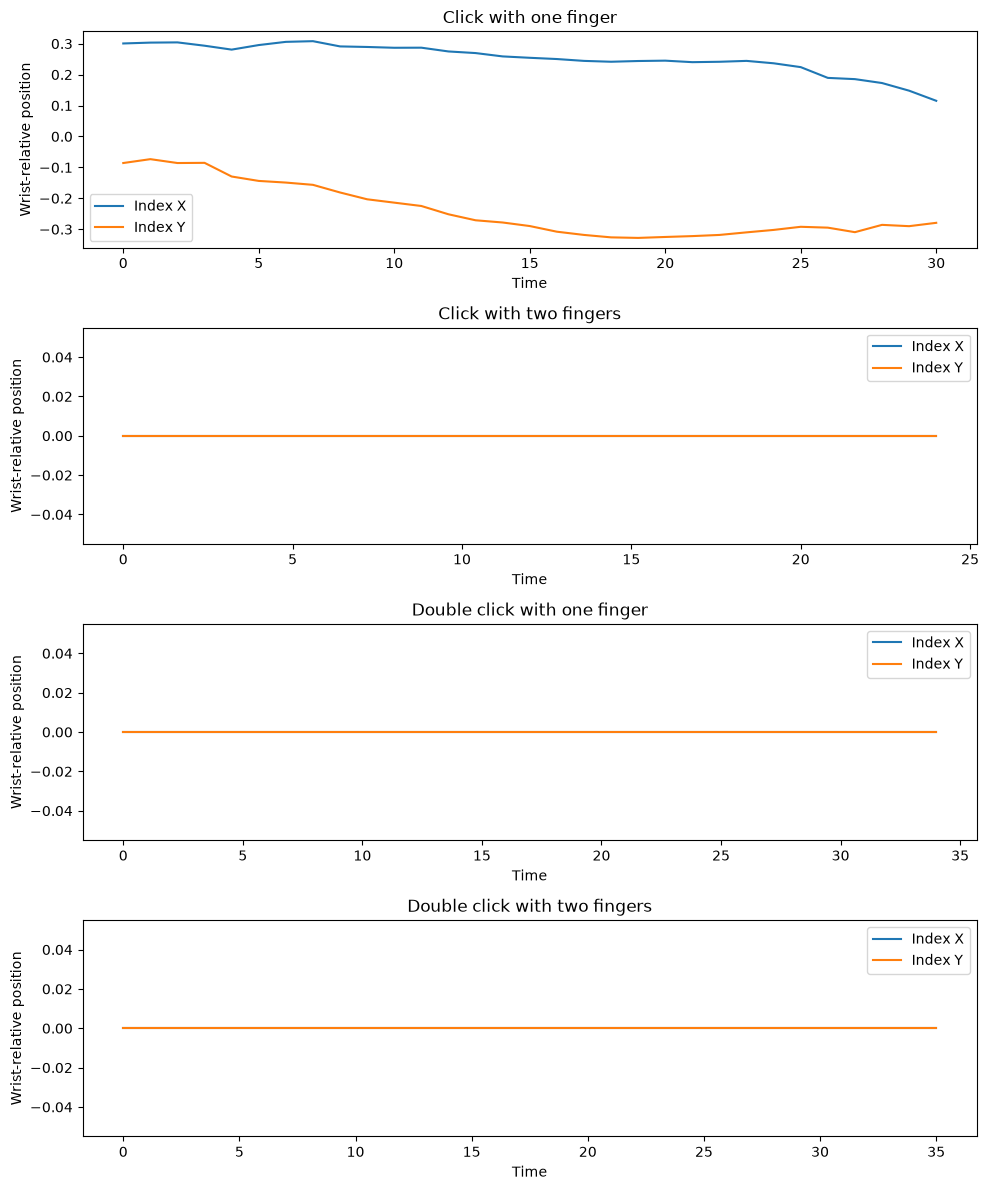

In [24]:
import matplotlib.pyplot as plt

gesture_to_id = {
    "Click with one finger": 4,
    "Click with two fingers": 5,
    "Double click with one finger": 11,
    "Double click with two fingers": 12,
}

representatives = {}

for sequence in train_sequences:
    if sequence.class_id in gesture_to_id.values():
        if sequence.class_id not in representatives:
            representatives[sequence.class_id] = sequence

fig, axes = plt.subplots(
    4,
    1,
    figsize=(10, 12),
)

for axis, (gesture_name, class_id) in zip(
    axes,
    gesture_to_id.items(),
):
    sequence = representatives[class_id]

    # Index fingertip = landmark 8
    # x = feature 24, y = feature 25
    index_x = sequence.landmarks[:, 8 * 3]
    index_y = sequence.landmarks[:, 8 * 3 + 1]

    axis.plot(index_x, label="Index X")
    axis.plot(index_y, label="Index Y")

    axis.set_title(gesture_name)
    axis.set_xlabel("Time")
    axis.set_ylabel("Wrist-relative position")
    axis.legend()

plt.tight_layout()
plt.show()

In [25]:
representatives = {}

for class_id in gesture_to_id.values():

    candidates = [
        sequence
        for sequence in train_sequences
        if sequence.class_id == class_id
    ]

    # Pick the sequence with the highest hand-detection rate
    representative = max(
        candidates,
        key=lambda sequence: sequence.hand_detected.mean()
    )

    representatives[class_id] = representative


for gesture_name, class_id in gesture_to_id.items():
    sequence = representatives[class_id]

    print(
        f"{gesture_name}: "
        f"length={len(sequence.landmarks)}, "
        f"detection_rate={sequence.hand_detected.mean():.3f}"
    )

Click with one finger: length=31, detection_rate=1.000
Click with two fingers: length=28, detection_rate=1.000
Double click with one finger: length=59, detection_rate=1.000
Double click with two fingers: length=41, detection_rate=1.000


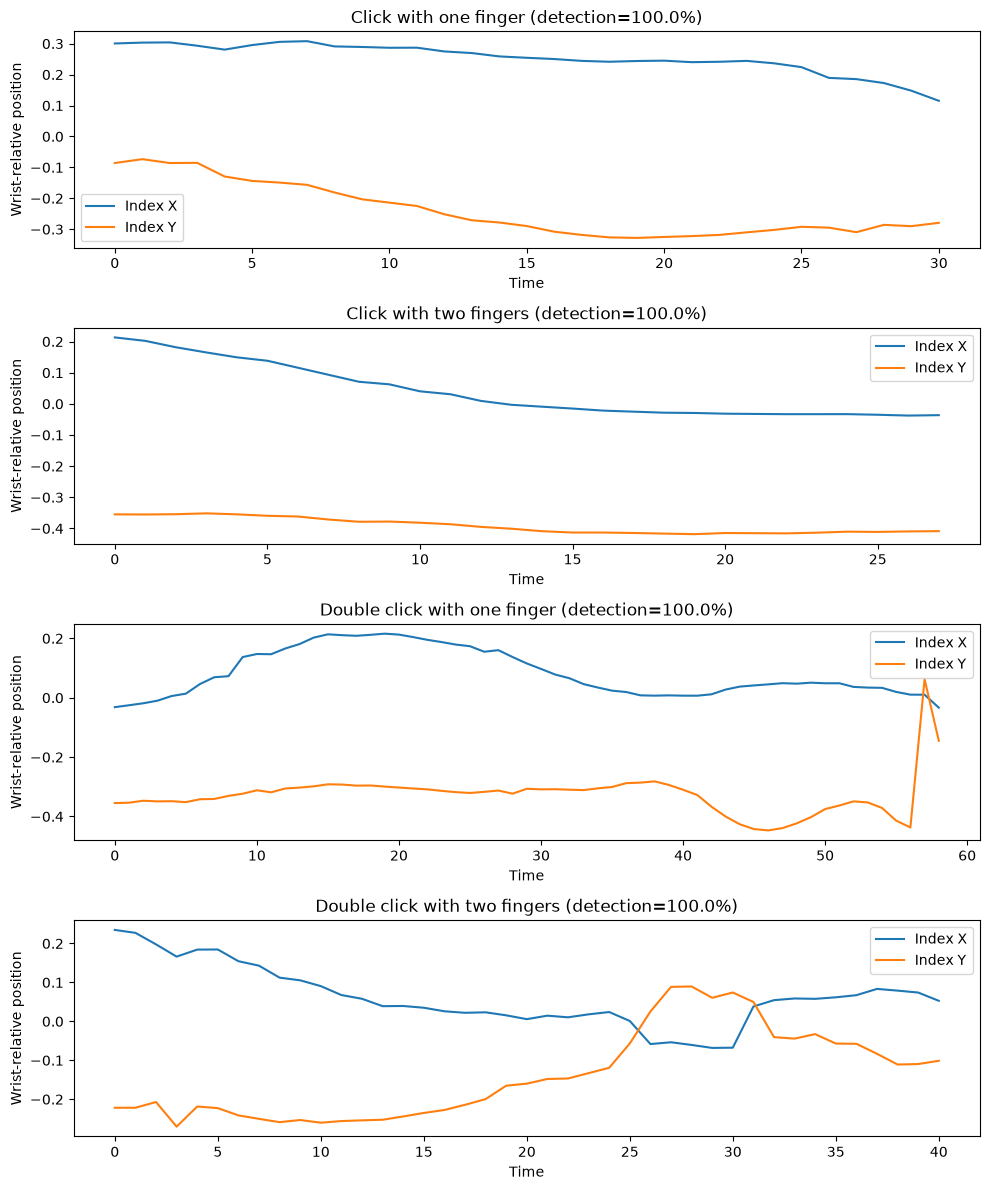

In [26]:
fig, axes = plt.subplots(
    4,
    1,
    figsize=(10, 12),
)

for axis, (gesture_name, class_id) in zip(
    axes,
    gesture_to_id.items(),
):
    sequence = representatives[class_id]

    index_x = sequence.landmarks[:, 8 * 3]
    index_y = sequence.landmarks[:, 8 * 3 + 1]

    axis.plot(index_x, label="Index X")
    axis.plot(index_y, label="Index Y")

    axis.set_title(
        f"{gesture_name} "
        f"(detection={sequence.hand_detected.mean():.1%})"
    )

    axis.set_xlabel("Time")
    axis.set_ylabel("Wrist-relative position")
    axis.legend()

plt.tight_layout()
plt.show()

In [27]:
# Evaluate the trained hybrid model on the training set

hybrid_model.eval()

train_predictions = []
train_true_labels = []

with torch.no_grad():
    for sequences, lengths, labels in train_loaders["hybrid"]:
        sequences = sequences.to(DEVICE)

        logits = hybrid_model(
            sequences,
            lengths,
        )

        predictions = logits.argmax(dim=1)

        train_predictions.extend(
            predictions.cpu().numpy()
        )

        train_true_labels.extend(
            labels.numpy()
        )

train_predictions = np.asarray(train_predictions)
train_true_labels = np.asarray(train_true_labels)

print(
    "Training accuracy:",
    (train_predictions == train_true_labels).mean()
)

print(
    classification_report(
        train_true_labels,
        train_predictions,
        target_names=gesture_names,
        digits=3,
    )
)

Training accuracy: 0.7620772946859904
                               precision    recall  f1-score   support

     Pointing with one finger      0.979     0.951     0.965       593
    Pointing with two fingers      0.907     0.993     0.948       592
        Click with one finger      0.458     0.737     0.565       118
       Click with two fingers      0.348     0.068     0.113       118
                     Throw up      0.797     0.500     0.615       118
                   Throw down      0.892     0.832     0.861       119
                   Throw left      0.911     0.949     0.929       118
                  Throw right      0.870     0.797     0.832       118
                   Open twice      0.545     0.568     0.556       118
 Double click with one finger      0.529     0.314     0.394       118
Double click with two fingers      0.351     0.720     0.472       118
                      Zoom in      0.442     0.517     0.477       118
                     Zoom out      0.5